<a href="https://colab.research.google.com/github/zwimpee/cursivetransformer/blob/main/visualize_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone the cursivetransformer repository and install its requirements
!rm -rf cursivetransformer && git clone https://github.com/zwimpee/cursivetransformer.git
!cd cursivetransformer && pip install -r requirements.txt
!wandb login

Cloning into 'cursivetransformer'...
remote: Enumerating objects: 3039, done.
remote: Counting objects: 100% (560/560), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 3039 (delta 496), reused 432 (delta 402), pack-reused 2479 (from 1)
Receiving objects: 100% (3039/3039), 64.44 MiB | 14.95 MiB/s, done.
Resolving deltas: 100% (1693/1693), done.
  Cloning https://github.com/callummcdougall/CircuitsVis.git to /tmp/pip-req-build-vnrgj5cn
  Running command git clone --filter=blob:none --quiet https://github.com/callummcdougall/CircuitsVis.git /tmp/pip-req-build-vnrgj5cn
  Resolved https://github.com/callummcdougall/CircuitsVis.git to commit 1e6129d08cae7af9242d9ab5d3ed322dd44b4dd3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which 

In [2]:
import sys
sys.path.append('/content/cursivetransformer/')

import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from cursivetransformer.model import get_all_args, get_checkpoint
from cursivetransformer.data import create_datasets
from cursivetransformer.sample import generate_n_words, plot_strokes

In [3]:
args = get_all_args(False)
args.wandb_project = 'bigbank_2k'
args.load_from_run_id = '7e9hz1og'
args.max_seq_length = 1250
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
train_dataset, test_dataset = create_datasets(args)
args.block_size = train_dataset.get_stroke_seq_length()
args.context_block_size = train_dataset.get_text_seq_length()
args.vocab_size = train_dataset.get_vocab_size()
args.context_vocab_size = train_dataset.get_char_vocab_size()
print(f"Dataset determined that: {args.vocab_size=}, {args.block_size=}")
model, _, _, _, _ = get_checkpoint(args, sample_only=True)

Trying to load dataset file from /content/cursivetransformer/data/bigbank.json.zip
Succeeded in loading the bigbank dataset; contains 2000 items.
For a dataset of 1900 examples we can generate 205257574037880 combinations of 5 examples.
Generating 497000 random combinations.
For a dataset of 100 examples we can generate 75287520 combinations of 5 examples.
Generating 3000 random combinations.
Number of examples in the train dataset: 497000
Number of examples in the test dataset: 3000
Max token sequence length: 1250
Number of unique characters in the ascii vocabulary: 71
Ascii vocabulary:
	" enaitoshrdx.vpukbgfcymzw1lqj804I92637OTAS5N)EHR"'(BCQLMWYU,ZF!DXV?KPGJ"
Split up the dataset into 497000 training examples and 3000 test examples
Dataset determined that: args.vocab_size=382, args.block_size=1250
Number of Transformer parameters: 379392
Model #params: 403840
Finding latest checkpoint for W&B run id 7e9hz1og
  model:best_checkpoint:v129
  model:best_checkpoint:v130
  model:best_check

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  


Generating 4 words with text: 'Hello world'
Model device: 2
Model is on device: cuda:0
Expected 5 words, got 2; padding with 'hello'
Processed text: 'Hello world hello hello'
Context shape: torch.Size([1, 50])
X_init shape: torch.Size([1, 178])
Generating for 1072 steps
Starting generation with max_new_tokens: 1072
Block size: 1250
Generating for 894 steps
Generation step: 0/894
Generation step: 100/894
Generation step: 200/894
Generation step: 300/894
Generation step: 400/894
Generation step: 500/894
Generation step: 600/894
Generation step: 700/894
Generation step: 800/894
Generation successful, X_samp shape: torch.Size([1, 1072])
Generation completed successfully


(<Figure size 1800x300 with 1 Axes>, <Axes: title={'center': 'Hello world'}>)

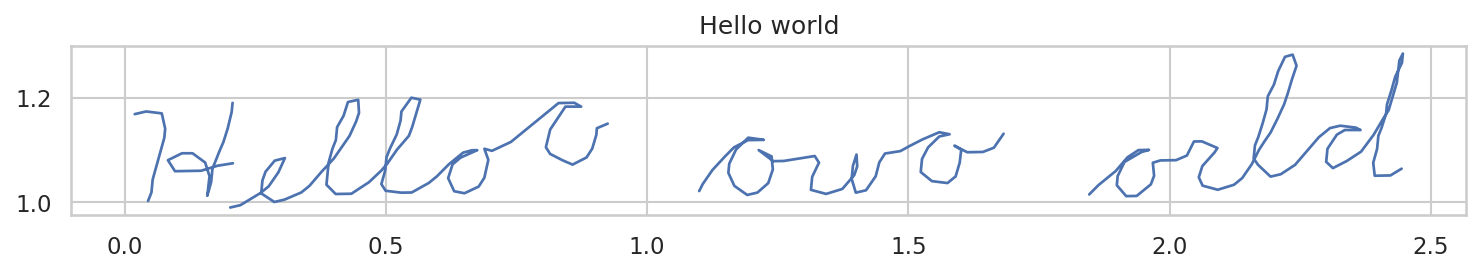

In [4]:
# Generate a sample
text = "Hello world"
n_words = 2
temperature = 1.0
top_k = None
do_sample = True
num_steps = 1250

offset_samp, point_samp, attention_patterns = generate_n_words(model, test_dataset, text, n_words, temperature, top_k, do_sample, num_steps, return_attention_patterns=True)

# Plot the generated strokes
plot_strokes(point_samp, title=text)

In [6]:
attention_patterns

[{'transformer.h.0.attn': tensor([[[ 10.4719,   0.9835, -14.1242,  ...,   5.2536,   6.3948,  13.3390],
           [  5.5541, -26.2986, -24.7193,  ...,  15.3377,  27.8762,   2.8744],
           [  3.3100,   6.0331,  -2.9364,  ...,   6.2578,  11.2072,   1.8693],
           ...,
           [  7.1942,  -4.4085,   3.0800,  ...,  -6.9942,   8.7050,   3.5170],
           [ 13.0827,   1.1871,   0.8916,  ...,  -0.8914,   2.1578,  -2.0060],
           [-10.2062,  -6.3983,  -5.6720,  ...,   7.5630,  -1.3357,   9.9049]]]),
  'transformer.h.1.attn': tensor([[[-24.0928,   2.3916,  -2.3352,  ...,  29.8377, -21.4056, -13.8975],
           [-19.9689,  -3.3553,   6.7583,  ...,   0.6090, -11.8562,  -2.9064],
           [-20.9997,  -2.6016,   5.9505,  ...,   6.3498, -13.1598,  -5.0132],
           ...,
           [-16.6983,  19.3979,   9.7962,  ...,  12.2881,   3.9438,  -1.2602],
           [  9.4377,  -0.5578,  34.3448,  ...,  16.3995, -12.4549,  18.1046],
           [ -5.8271,  15.4735,  -3.6653,  ..., 

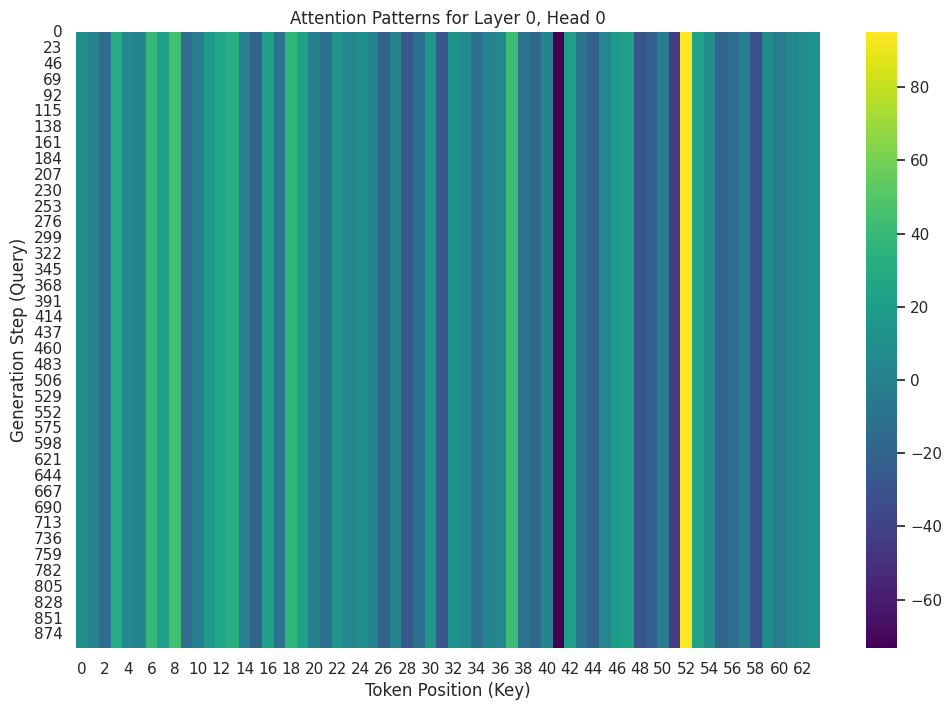

In [7]:
def plot_attention_patterns(attention_patterns, layer, head):
    # Extract attention patterns for the specified layer and head
    layer_patterns = [step[f'transformer.h.{layer}.attn'] for step in attention_patterns]
    head_patterns = [pattern[0, head] for pattern in layer_patterns]

    # Create a heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(head_patterns, cmap='viridis')
    plt.title(f'Attention Patterns for Layer {layer}, Head {head}')
    plt.xlabel('Token Position (Key)')
    plt.ylabel('Generation Step (Query)')
    plt.show()

# Plot attention patterns for a specific layer and head
plot_attention_patterns(attention_patterns, layer=0, head=0)

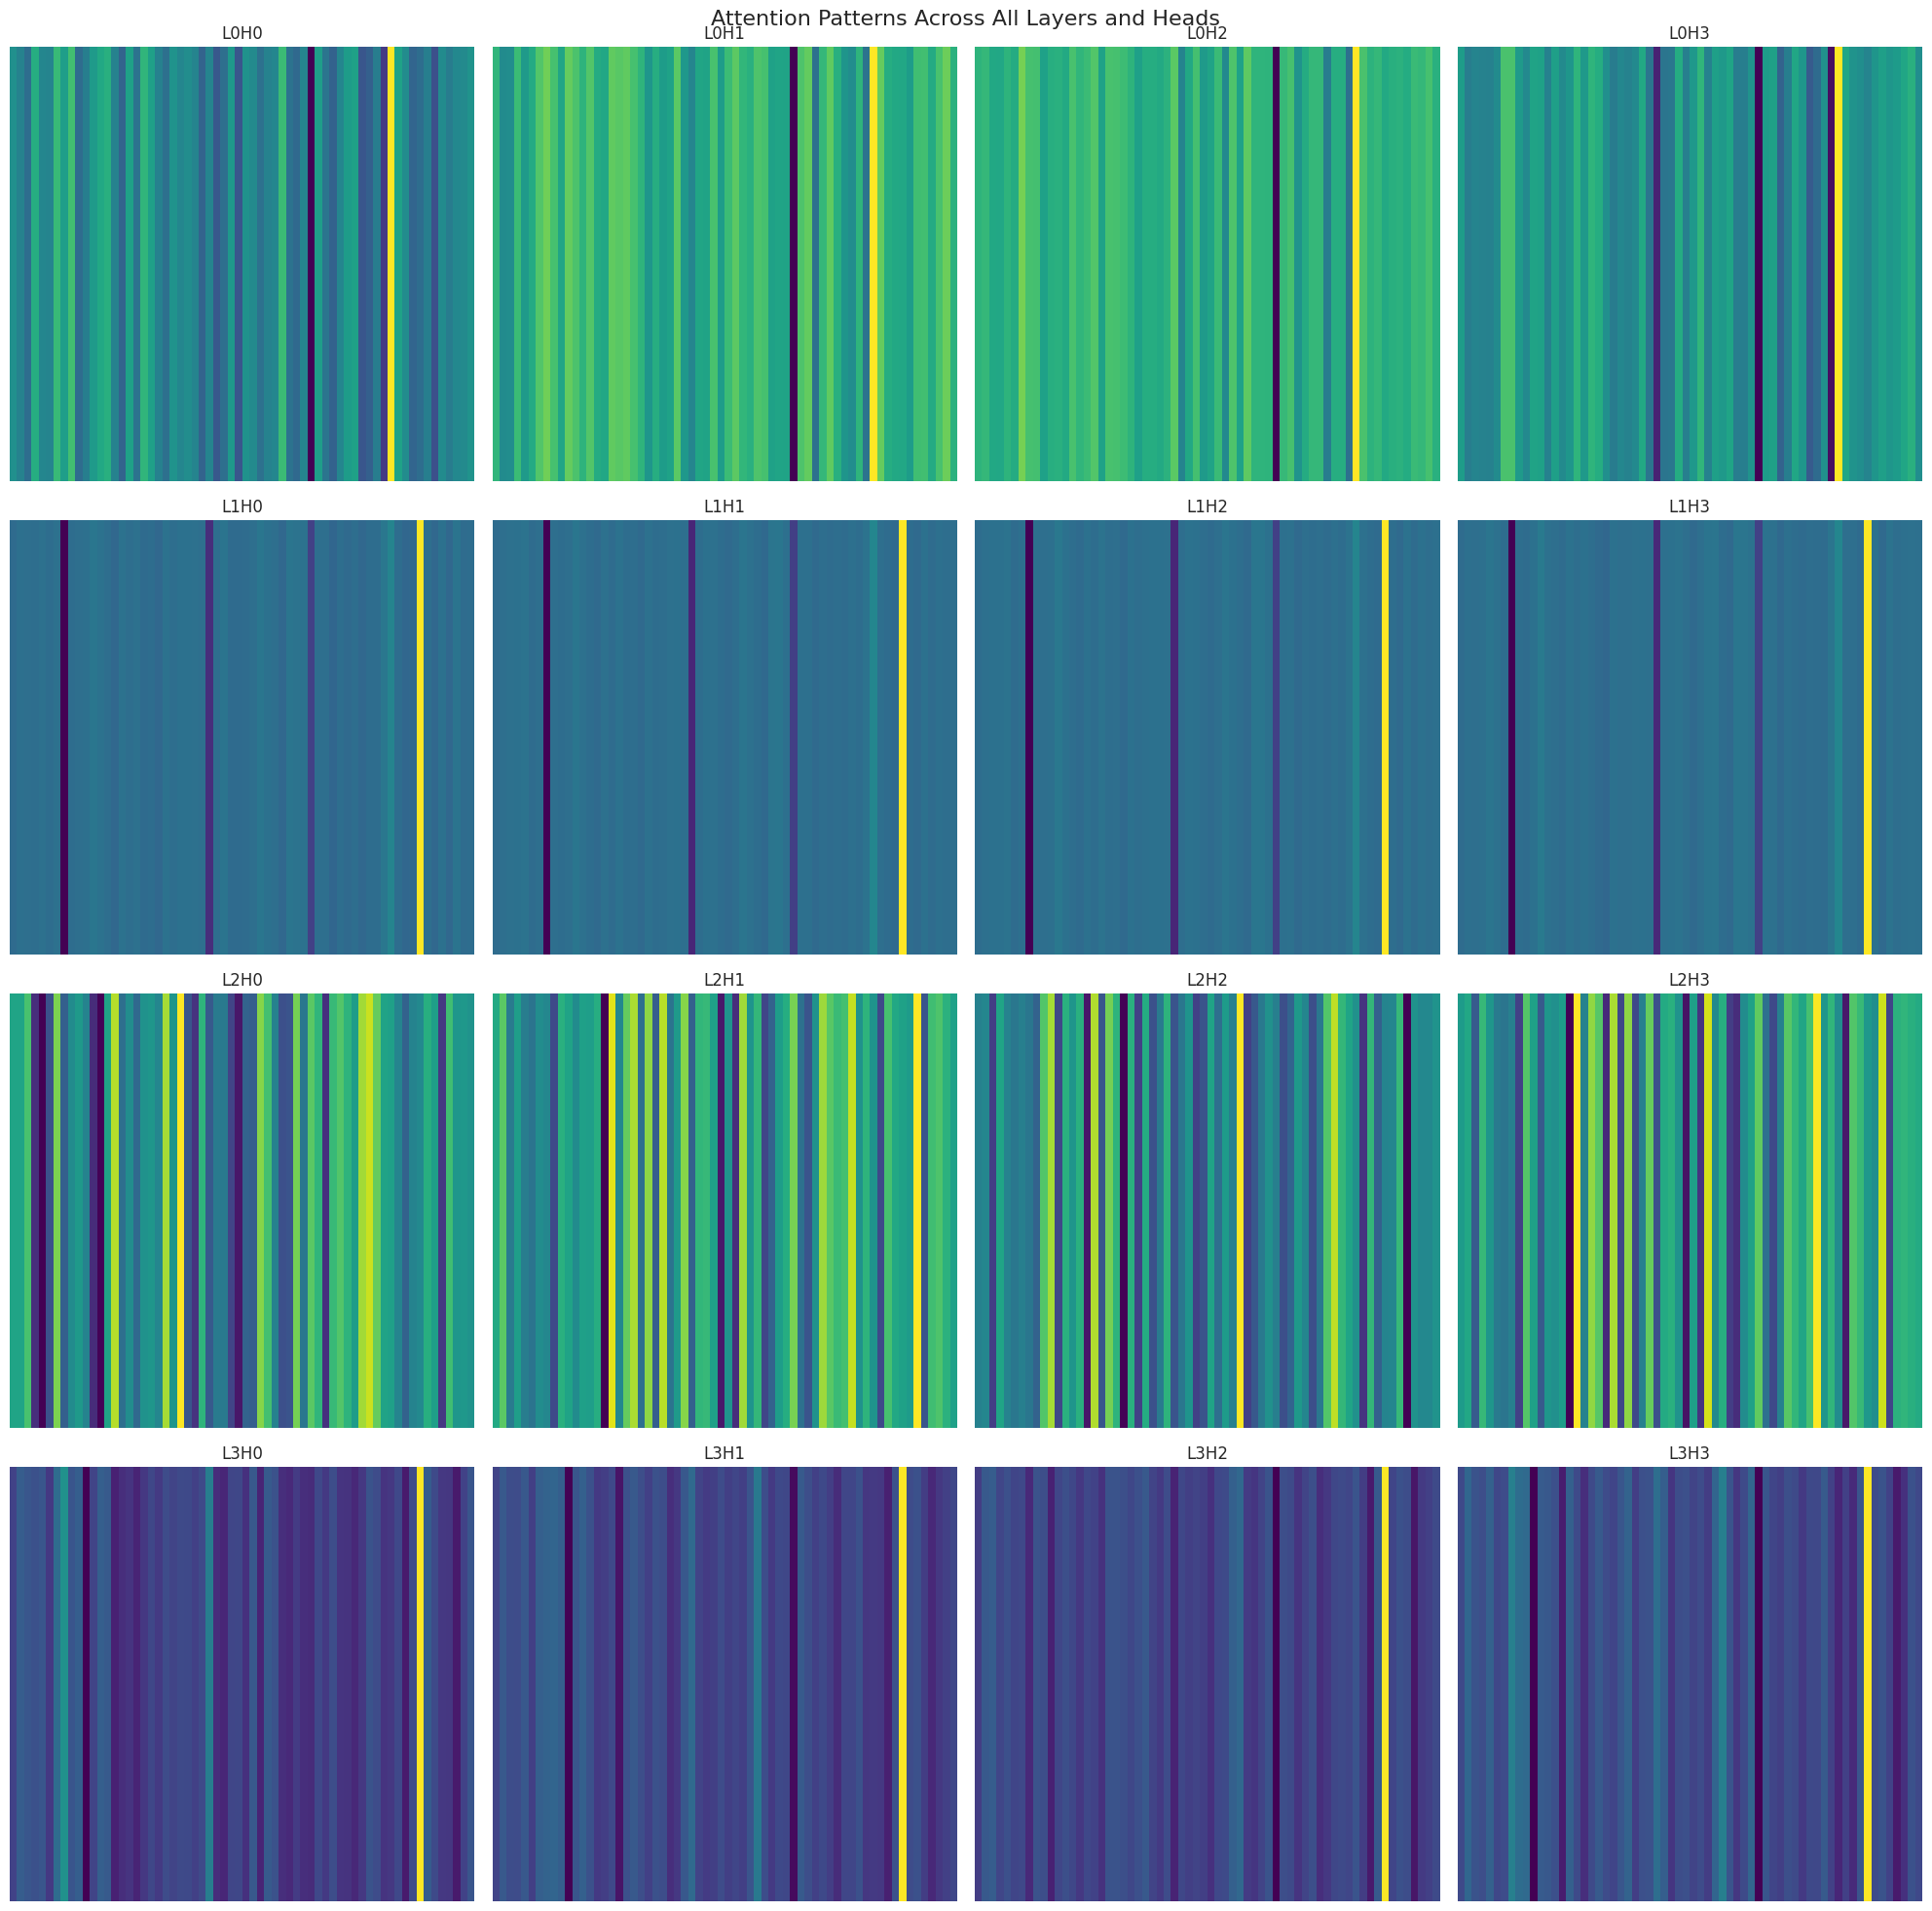

In [9]:
num_layers = model.config.n_layer
num_heads = model.config.n_ctx_head

fig, axes = plt.subplots(num_layers, num_heads, figsize=(20, 5*num_layers))
fig.suptitle('Attention Patterns Across All Layers and Heads', fontsize=16)

for layer in range(num_layers):
    for head in range(num_heads):
        layer_patterns = [step[f'transformer.h.{layer}.attn'] for step in attention_patterns]
        head_patterns = [pattern[0, head] for pattern in layer_patterns]

        ax = axes[layer, head]
        sns.heatmap(head_patterns, cmap='viridis', ax=ax, cbar=False)
        ax.set_title(f'L{layer}H{head}')
        ax.axis('off')

plt.tight_layout()
plt.show()